In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import mlflow
import mlflow.xgboost
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from itertools import product

warnings.filterwarnings('ignore')

TARGET= 'consommation_telerelevee_residentielle'

OTHERS= [
    'consommation_telerelevee_hta',
    'consommation_telerelevee_professionnelle',
    'consommation_telerelevee_btsup',
]

HORIZON=7*48

In [57]:
df=pd.read_csv("C:/Users/T14s/Desktop/ml-project/data/features_with_lags.csv",parse_dates=['datetime'])
df = df.set_index('datetime')

In [54]:
df.columns

Index(['year_utc', 'month_utc', 'day', 'day_of_week', 'est_weekend',
       'est_ferie', 'hour_utc', 'minute_utc', 'temperature_reelle_lissee',
       'temperature_normale_lissee', 'ecart_temperature', 'temp_x_weekend',
       'temp_x_ferier', 'degre_jour_chauffage', 'degre_jour_clim',
       'pseudo_rayonnement', 'consommation_telerelevee_hta',
       'consommation_telerelevee_btsup',
       'consommation_telerelevee_professionnelle',
       'consommation_telerelevee_residentielle', 'halfhour_of_day',
       'jour_fetes', 'consommation_telerelevee_hta_lag_336',
       'consommation_telerelevee_hta_lag_672',
       'consommation_telerelevee_hta_lag_1344',
       'consommation_telerelevee_btsup_lag_336',
       'consommation_telerelevee_btsup_lag_672',
       'consommation_telerelevee_btsup_lag_1344',
       'consommation_telerelevee_professionnelle_lag_336',
       'consommation_telerelevee_professionnelle_lag_672',
       'consommation_telerelevee_professionnelle_lag_1344',
       'co

In [66]:
featurs_col=['year_utc', 'month_utc', 'day', 'day_of_week', 'est_weekend',
              'est_ferie', 'hour_utc', 'minute_utc', 'temperature_reelle_lissee',
              'temperature_normale_lissee', 'ecart_temperature', 'temp_x_weekend',
              'temp_x_ferier', 'degre_jour_chauffage', 'degre_jour_clim', 'jour_fetes',
              'pseudo_rayonnement', 'consommation_telerelevee_residentielle_lag_336',
              'consommation_telerelevee_residentielle_lag_672',
              'consommation_telerelevee_residentielle_lag_1344']
target='consommation_telerelevee_residentielle'

In [67]:
X=df[featurs_col]
y=df[target]

In [68]:
X_train_full= X.iloc[:-HORIZON]  
X_test= X.iloc[-HORIZON:]   
y_train_full= y.iloc[:-HORIZON]
y_test= y.iloc[-HORIZON:]

In [69]:

print('Features finales :', featurs_col)
print('Nombre :', len(featurs_col))

X_train_final= X_train_full[featurs_col]
X_test_final= X_test[featurs_col]

Features finales : ['year_utc', 'month_utc', 'day', 'day_of_week', 'est_weekend', 'est_ferie', 'hour_utc', 'minute_utc', 'temperature_reelle_lissee', 'temperature_normale_lissee', 'ecart_temperature', 'temp_x_weekend', 'temp_x_ferier', 'degre_jour_chauffage', 'degre_jour_clim', 'jour_fetes', 'pseudo_rayonnement', 'consommation_telerelevee_residentielle_lag_336', 'consommation_telerelevee_residentielle_lag_672', 'consommation_telerelevee_residentielle_lag_1344']
Nombre : 20


In [70]:
PARAM_GRID = {
    'n_estimators' : [300, 500,],
    'max_depth'    : [4, 6,],
    'learning_rate': [0.05, 0.1],
    'subsample'    : [0.8, 1.0],
}

keys= list(PARAM_GRID.keys())
values= list(PARAM_GRID.values())
combinations= [dict(zip(keys, v)) for v in product(*values)]

tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=HORIZON 
)

mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment('XGBoost_residentielle01')

best_mae= float('inf')
best_params= None
results= []

for i, params in enumerate(combinations):

    fold_maes= []
    fold_rmses= []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_final)):

        X_cv_train= X_train_final.iloc[train_idx]
        y_cv_train= y_train_full.iloc[train_idx]
        X_cv_val= X_train_final.iloc[val_idx]
        y_cv_val= y_train_full.iloc[val_idx]

        model = XGBRegressor(
            **params,
            random_state=42,
            n_jobs=-1
        )
        model.fit(
            X_cv_train, y_cv_train,
            eval_set=[(X_cv_val, y_cv_val)],
            verbose=False
        )

        preds = model.predict(X_cv_val)
        fold_maes.append(mean_absolute_error(y_cv_val, preds))
        fold_rmses.append(np.sqrt(mean_squared_error(y_cv_val, preds)))

    mae_mean  = np.mean(fold_maes)
    mae_std   = np.std(fold_maes)
    rmse_mean = np.mean(fold_rmses)

    results.append({**params, 'mae_mean': mae_mean, 'mae_std': mae_std})

    with mlflow.start_run(run_name=f'run_{i+1:02d}'):
        mlflow.log_params(params)
        mlflow.log_param('target', TARGET)
        mlflow.log_param('n_features_selected', len(featurs_col))
        mlflow.log_param('horizon', 'J+7')

        mlflow.log_metric('cv_mae_mean', mae_mean)
        mlflow.log_metric('cv_mae_std', mae_std)
        mlflow.log_metric('cv_rmse_mean', rmse_mean)

        for f, m in enumerate(fold_maes):
            mlflow.log_metric(f'fold_{f+1}_mae', m)

    if mae_mean < best_mae:
        best_mae= mae_mean
        best_params= params

    print(f'  [{i+1:2d}/{len(combinations)}] MAE={mae_mean:.2f} ± {mae_std:.2f} | {params}')

print(f'\nGrid Search terminé')
print(f'Meilleurs paramètres: {best_params}')
print(f'Meilleure MAE CV: {best_mae:.2f}')


🏃 View run run_01 at: http://127.0.0.1:5000/#/experiments/4/runs/8aa935a6d5954063855eead718058c0a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
  [ 1/16] MAE=28697746.00 ± 13835395.82 | {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8}
🏃 View run run_02 at: http://127.0.0.1:5000/#/experiments/4/runs/a88f307f45224f84b620f9126e48472b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
  [ 2/16] MAE=29379706.40 ± 14122004.43 | {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 1.0}
🏃 View run run_03 at: http://127.0.0.1:5000/#/experiments/4/runs/ce7ed25705444652b17a72ff5950bd67
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
  [ 3/16] MAE=26271767.20 ± 11622800.82 | {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8}
🏃 View run run_04 at: http://127.0.0.1:5000/#/experiments/4/runs/71c292b8e6214907ad0785bf6229375b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
  [ 4/

MAE: 23,542,202
RMSE: 28,789,149
MAPE: 4.09%
R2: 0.5891


2026/04/12 21:18:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run FINAL_best_model at: http://127.0.0.1:5000/#/experiments/4/runs/f5d5661232044a67b343052cc5fc70ae
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


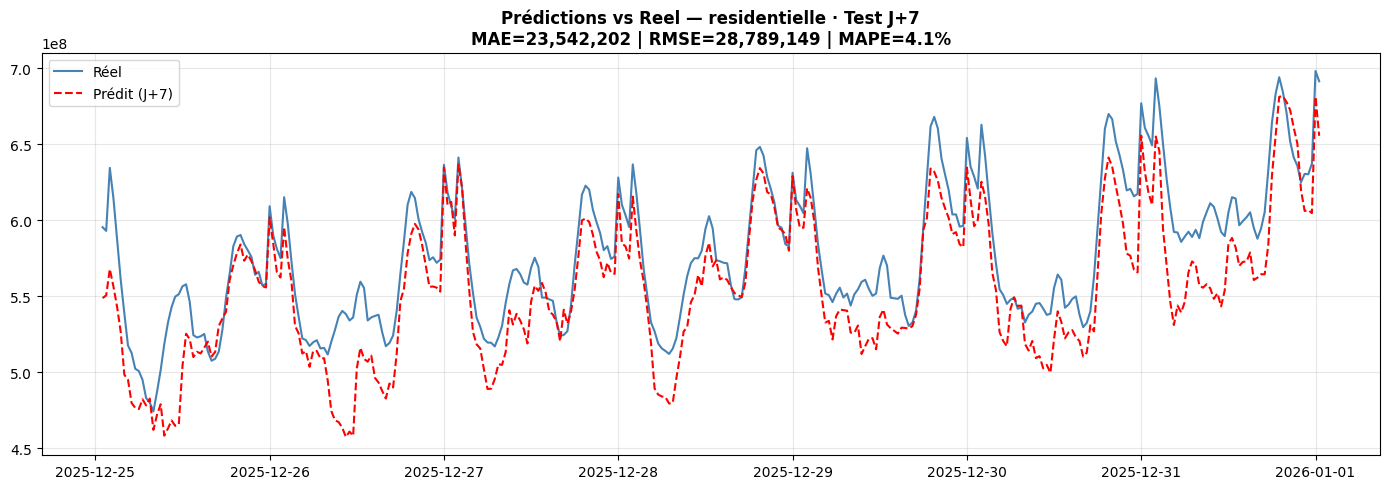

In [75]:
final_model = XGBRegressor(**best_params, random_state=42, n_jobs=-1)
final_model.fit(X_train_final, y_train_full)

y_pred= final_model.predict(X_test_final)
y_true_arr = np.array(y_test).flatten()
y_pred_arr = np.array(y_pred).flatten()

mae= mean_absolute_error(y_true_arr, y_pred_arr)
rmse= np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
mape= np.mean(np.abs((y_true_arr - y_pred_arr) / y_true_arr)) * 100
r2= r2_score(y_true_arr, y_pred_arr)

print(f'MAE: {mae:,.0f}')
print(f'RMSE: {rmse:,.0f}')
print(f'MAPE: {mape:.2f}%')
print(f'R2: {r2:.4f}')

with mlflow.start_run(run_name='FINAL_best_model'):
    mlflow.log_params(best_params)
    mlflow.log_param('target', TARGET)
    mlflow.log_param('n_features_selected', len(featurs_col))
    mlflow.log_param('features_selected', str(featurs_col))
    mlflow.log_param('horizon', 'J+7')

    mlflow.log_metric('test_mae', mae)
    mlflow.log_metric('test_rmse', rmse)
    mlflow.log_metric('test_mape', mape)
    mlflow.log_metric('cv_mae_best', best_mae)

    mlflow.xgboost.log_model(final_model, 'model')

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_test.index, y_test.values, 
        label='Réel', color='steelblue', linewidth=1.5)
ax.plot(y_test.index, y_pred, 
        label='Prédit (J+7)', color='red', linewidth=1.5, linestyle='--')

ax.set_title(f'Prédictions vs Reel — residentielle · Test J+7\n'
             f'MAE={mae:,.0f} | RMSE={rmse:,.0f} | MAPE={mape:.1f}%',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

MAE: 23,542,202
RMSE: 28,789,149
MAPE: 4.09%
R2: 0.5891


2026/04/12 21:18:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run FINAL_best_model at: http://127.0.0.1:5000/#/experiments/4/runs/06b072645acc48798e681c9cdc9585c2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


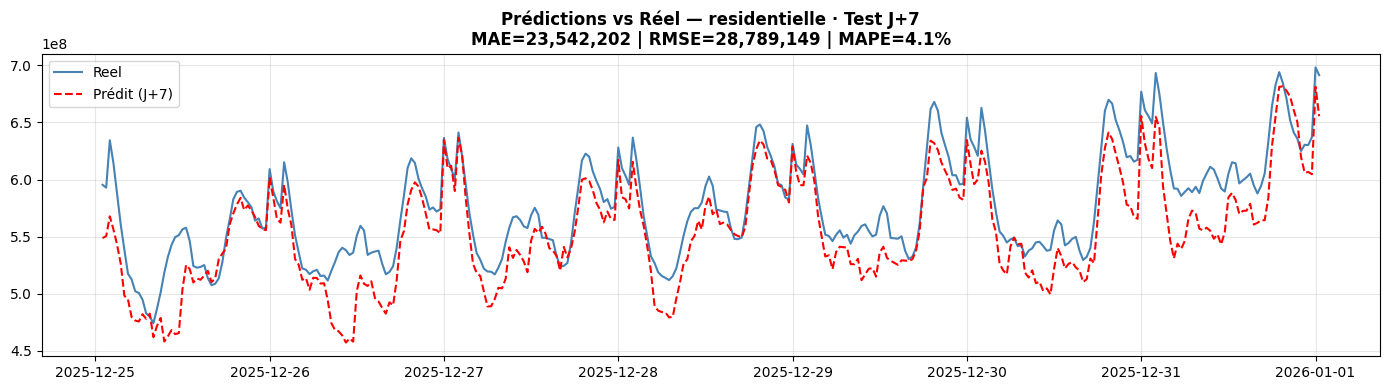

Registered model 'Enedis_residentielle' already exists. Creating a new version of this model...
2026/04/12 21:18:44 WARNING mlflow.tracking._model_registry.fluent: Run with id 06b072645acc48798e681c9cdc9585c2 has no artifacts at artifact path 'model', registering model based on models:/m-a779e75844f74e19be6996c08960ae76 instead
2026/04/12 21:18:44 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Enedis_residentielle, version 3


🏃 View run FINAL_best_model at: http://127.0.0.1:5000/#/experiments/4/runs/06b072645acc48798e681c9cdc9585c2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Created version '3' of model 'Enedis_residentielle'.


<ModelVersion: aliases=[], creation_timestamp=1776025124138, current_stage='Production', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1776025124207, metrics=None, model_id=None, name='Enedis_residentielle', params=None, run_id='06b072645acc48798e681c9cdc9585c2', run_link='', source='models:/m-a779e75844f74e19be6996c08960ae76', status='READY', status_message=None, tags={}, user_id='', version='3', workspace='default'>

In [76]:
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient

final_model = XGBRegressor(**best_params, random_state=42, n_jobs=-1)
final_model.fit(X_train_final, y_train_full)

y_pred= final_model.predict(X_test_final)
y_true_arr = np.array(y_test).flatten()
y_pred_arr = np.array(y_pred).flatten()

mae= mean_absolute_error(y_true_arr, y_pred_arr)
rmse= np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
mape= np.mean(np.abs((y_true_arr - y_pred_arr) / y_true_arr)) * 100
r2= r2_score(y_true_arr, y_pred_arr)

print(f'MAE: {mae:,.0f}')
print(f'RMSE: {rmse:,.0f}')
print(f'MAPE: {mape:.2f}%')
print(f'R2: {r2:.4f}')

signature = infer_signature(
    model_input=X_train_final,
    model_output=final_model.predict(X_train_final)
)

with mlflow.start_run(run_name='FINAL_best_model') as run:
    final_run_id = run.info.run_id

    mlflow.set_tag("segment","residentielle")
    mlflow.set_tag("statut","production")
    mlflow.set_tag("horizon","J+7")
    mlflow.set_tag("vs_sarima_mape","-63%")
    mlflow.set_tag("n_features",len(featurs_col))

    mlflow.log_params(best_params)
    mlflow.log_param('target',TARGET)
    mlflow.log_param('features_selected',str(featurs_col))
    mlflow.log_param('n_features_selected', len(featurs_col))
    mlflow.log_param('horizon','J+7')

    mlflow.log_metric('test_mae',mae)
    mlflow.log_metric('test_rmse',rmse)
    mlflow.log_metric('test_mape',mape)
    mlflow.log_metric('test_r2',r2)
    mlflow.log_metric('cv_mae_best',best_mae)

    mlflow.xgboost.log_model(
        xgb_model=final_model,
        artifact_path="model",
        signature=signature,
        input_example=X_test_final.iloc[:3]
    )

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test.index, y_true_arr, color='steelblue', label='Reel', linewidth=1.5)
ax.plot(y_test.index, y_pred_arr, color='red', label='Prédit (J+7)',
        linewidth=1.5, linestyle='--')
ax.set_title(f'Prédictions vs Réel — residentielle · Test J+7\n'
             f'MAE={mae:,.0f} | RMSE={rmse:,.0f} | MAPE={mape:.1f}%',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("predictions_residentielle.png", dpi=120, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact("predictions_residentielle.png")

client = MlflowClient()
registered = mlflow.register_model(f"runs:/{final_run_id}/model", "Enedis_residentielle")
client.transition_model_version_stage(
    name="Enedis_residentielle",
    version=registered.version,
    stage="Production"
)